<a href="https://colab.research.google.com/github/tciodaro/GRLCDDR1C1-N2-L2-PB/blob/main/validacao_cruzada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

fname = 'drive/MyDrive/Curso Projeto de Bloco: Inteligência Artificial e Machine Learning (GRLCDDR1C1-N2-L2)/dataset_vinhos.csv'

target_col = 'target'
target_col_label='target_label'

cat_cols = ['type']


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:

wine = pd.read_csv(fname, sep=';')
wine


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target,target_label,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0,baixa qualidade,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0,baixa qualidade,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0,baixa qualidade,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1,alta qualidade,red
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,0,baixa qualidade,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5315,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1,alta qualidade,white
5316,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,0,baixa qualidade,white
5317,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1,alta qualidade,white
5318,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1,alta qualidade,white


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Re-defining these variables as their original defining cell was not executed
target_col = 'target'
target_col_label='target_label'
cat_cols = ['type']

# Separate features (X) and target (y)
y = wine[target_col]
X = wine.drop(columns=[target_col, target_col_label])

# Identify numerical features
num_cols = [col for col in X.columns if col not in cat_cols]

# Split data into development and validation sets (80/20 ratio)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Data splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"Numerical columns identified: {num_cols}")
print(f"Categorical columns identified: {cat_cols}")

Data splitting complete.
X_train shape: (4256, 12)
X_val shape: (1064, 12)
y_train shape: (4256,)
y_val shape: (1064,)
Numerical columns identified: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Categorical columns identified: ['type']


## Create Preprocessing Pipeline

### Subtask:
Build a preprocessing pipeline that includes `StandardScaler` for numerical features and `OrdinalEncoder` for the categorical columns specified in `cat_cols`. Use `ColumnTransformer` to apply these transformations to the correct columns.


**Reasoning**:
The subtask requires building a preprocessing pipeline. This step involves importing necessary transformers and creating instances of `StandardScaler` and `OrdinalEncoder` to define how numerical and categorical features will be preprocessed.



In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Create a StandardScaler object for numerical features
scaler = StandardScaler()

# Create an OrdinalEncoder object for categorical features
# Corrected: 'handle_unknown' parameter for OrdinalEncoder should be 'use_encoded_value' in newer sklearn versions
# and 'unknown_value' must be specified when 'handle_unknown' is 'use_encoded_value'.
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Create a ColumnTransformer named preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, num_cols),
        ('cat', encoder, cat_cols)
    ],
    remainder='passthrough' # Ensure all other columns (if any) are passed through
)

print("Preprocessing pipeline components (scaler, encoder, preprocessor) created.")

Preprocessing pipeline components (scaler, encoder, preprocessor) created.


## Define and Train kNN Model

### Subtask:
Create a kNN classifier with 10 neighbors. Combine the preprocessing pipeline and the kNN model into a single `Pipeline`.


**Reasoning**:
First, I will import the `KNeighborsClassifier` and `Pipeline` classes. Then, I will instantiate `KNeighborsClassifier` with 10 neighbors and combine it with the `preprocessor` into a `Pipeline`.



In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Instantiate a KNeighborsClassifier with n_neighbors=10
knn_classifier = KNeighborsClassifier(n_neighbors=10)

# Create a Pipeline that combines the preprocessor and the kNN classifier
# This step needs to be re-executed after the preprocessor was updated.
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', knn_classifier)])

print("kNN classifier and preprocessing pipeline successfully combined into 'model'.")

kNN classifier and preprocessing pipeline successfully combined into 'model'.


**Reasoning**:
The `model` pipeline has now been correctly re-initialized with the updated `preprocessor`. I will re-execute the stratified k-fold cross-validation loop to ensure the model trains and evaluates correctly across all folds.



In [13]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Starting stratified k-fold cross-validation...")

accuracy_scores = []
precision_scores = []
recall_scores = []

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Train the model
    model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred = model.predict(X_test_fold)

    # Calculate scores
    accuracy = accuracy_score(y_test_fold, y_pred)
    precision = precision_score(y_test_fold, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_fold, y_pred, average='weighted', zero_division=0)

    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)

    print(f"Fold {fold + 1} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

print("Cross-validation complete. Calculating average scores...")

Starting stratified k-fold cross-validation...
Fold 1 - Accuracy: 0.7726, Precision: 0.7743, Recall: 0.7726
Fold 2 - Accuracy: 0.7500, Precision: 0.7498, Recall: 0.7500
Fold 3 - Accuracy: 0.7444, Precision: 0.7486, Recall: 0.7444
Fold 4 - Accuracy: 0.7312, Precision: 0.7294, Recall: 0.7312
Fold 5 - Accuracy: 0.7481, Precision: 0.7455, Recall: 0.7481
Fold 6 - Accuracy: 0.7124, Precision: 0.7121, Recall: 0.7124
Fold 7 - Accuracy: 0.7575, Precision: 0.7578, Recall: 0.7575
Fold 8 - Accuracy: 0.7350, Precision: 0.7324, Recall: 0.7350
Fold 9 - Accuracy: 0.7331, Precision: 0.7298, Recall: 0.7331
Fold 10 - Accuracy: 0.7538, Precision: 0.7526, Recall: 0.7538
Cross-validation complete. Calculating average scores...


**Reasoning**:
The cross-validation for all folds has been completed. Now, I need to calculate the average accuracy, precision, and recall from the scores collected in the `accuracy_scores`, `precision_scores`, and `recall_scores` lists, respectively. Then, I will print these average scores.



In [14]:
avg_accuracy = np.mean(accuracy_scores)
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)

print(f"Average Accuracy: {avg_accuracy:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")

Average Accuracy: 0.7438
Average Precision: 0.7432
Average Recall: 0.7438


In [16]:
from sklearn.model_selection import learning_curve

# Define scoring metrics
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted']

# Initialize dictionaries to store scores for each metric
all_train_scores = {}
all_val_scores = {}
train_sizes_output = None

print("Calculating learning curve scores for each metric...")

for metric in scoring_metrics:
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=skf,
        scoring=metric, # Pass one metric at a time
        n_jobs=-1,
        random_state=42
    )
    all_train_scores[metric] = train_scores
    all_val_scores[metric] = val_scores
    if train_sizes_output is None:
        train_sizes_output = train_sizes
    print(f"  - Metric '{metric}' calculated.")

print("Learning curve scores calculated successfully.")
print(f"Train sizes: {train_sizes_output}")
print(f"Shape of train_scores (example for accuracy): {all_train_scores['accuracy'].shape}")
print(f"Shape of val_scores (example for accuracy): {all_val_scores['accuracy'].shape}")

Calculating learning curve scores for each metric...
  - Metric 'accuracy' calculated.
  - Metric 'precision_weighted' calculated.
  - Metric 'recall_weighted' calculated.
Learning curve scores calculated successfully.
Train sizes: [ 478 1556 2633 3710 4788]
Shape of train_scores (example for accuracy): (5, 10)
Shape of val_scores (example for accuracy): (5, 10)


## Plot Learning Curve

### Subtask:
Plot the learning curve using the calculated training and cross-validation scores to visualize the model's performance with increasing training data. Include appropriate labels and a legend.


**Reasoning**:
To visualize the learning curves, I will import `matplotlib.pyplot` and iterate through the calculated scores for each metric (accuracy, precision, and recall). For each metric, I will plot the mean training and validation scores, along with their standard deviations, and add appropriate labels, titles, and legends to each plot.



Generating learning curve plots...


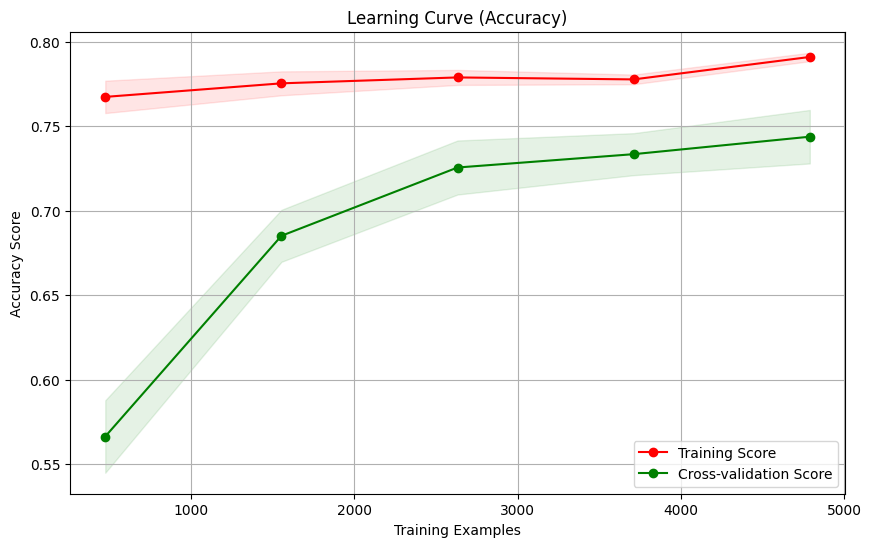

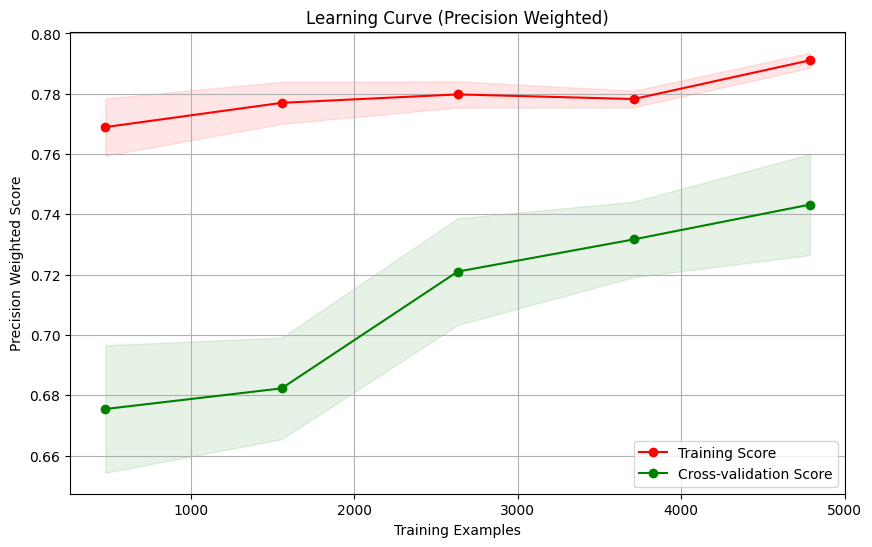

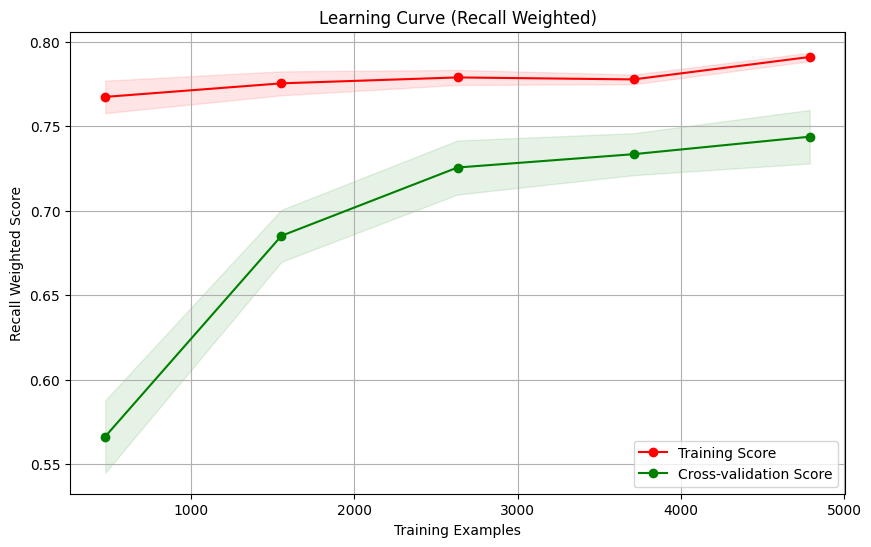

Learning curve plots generated.


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Plot learning curve for each metric
print("Generating learning curve plots...")

for i, metric in enumerate(scoring_metrics):
    # Calculate mean and standard deviation for training and validation scores
    mean_train_scores = np.mean(all_train_scores[metric], axis=1)
    std_train_scores = np.std(all_train_scores[metric], axis=1)
    mean_val_scores = np.mean(all_val_scores[metric], axis=1)
    std_val_scores = np.std(all_val_scores[metric], axis=1)

    # Create plot
    plt.figure(figsize=(10, 6))
    plt.title(f"Learning Curve ({metric.replace('_', ' ').title()})")
    plt.xlabel("Training Examples")
    plt.ylabel(f"{metric.replace('_', ' ').title()} Score")
    plt.grid()

    plt.plot(train_sizes_output, mean_train_scores, 'o-', color="r", label="Training Score")
    plt.fill_between(train_sizes_output, mean_train_scores - std_train_scores,
                     mean_train_scores + std_train_scores, alpha=0.1, color="r")

    plt.plot(train_sizes_output, mean_val_scores, 'o-', color="g", label="Cross-validation Score")
    plt.fill_between(train_sizes_output, mean_val_scores - std_val_scores,
                     mean_val_scores + std_val_scores, alpha=0.1, color="g")

    plt.legend(loc="best")
    plt.show()

print("Learning curve plots generated.")

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Initialize lists to store FPR, TPR, and AUC for training and test sets
fprs_train = []
tprs_train = []
aucs_train = []
fprs_test = []
tprs_test = []
aucs_test = []

# Initialize StratifiedKFold with 10 splits as specified in the subtask
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Starting stratified k-fold cross-validation for ROC curve data...")

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Fit the model
    model.fit(X_train_fold, y_train_fold)

    # Predict probabilities for the positive class on training data
    y_train_pred_proba = model.predict_proba(X_train_fold)[:, 1]

    # Predict probabilities for the positive class on test data
    y_test_pred_proba = model.predict_proba(X_test_fold)[:, 1]

    # Calculate ROC curve and AUC for training set
    fpr_train, tpr_train, _ = roc_curve(y_train_fold, y_train_pred_proba)
    auc_train = roc_auc_score(y_train_fold, y_train_pred_proba)
    fprs_train.append(fpr_train)
    tprs_train.append(tpr_train)
    aucs_train.append(auc_train)

    # Calculate ROC curve and AUC for test set
    fpr_test, tpr_test, _ = roc_curve(y_test_fold, y_test_pred_proba)
    auc_test = roc_auc_score(y_test_fold, y_test_pred_proba)
    fprs_test.append(fpr_test)
    tprs_test.append(tpr_test)
    aucs_test.append(auc_test)

    print(f"Fold {fold + 1} - Train AUC: {auc_train:.4f}, Test AUC: {auc_test:.4f}")

print("ROC curve data collection complete.")

Starting stratified k-fold cross-validation for ROC curve data...
Fold 1 - Train AUC: 0.8703, Test AUC: 0.8198
Fold 2 - Train AUC: 0.8723, Test AUC: 0.7971
Fold 3 - Train AUC: 0.8707, Test AUC: 0.8096
Fold 4 - Train AUC: 0.8708, Test AUC: 0.8092
Fold 5 - Train AUC: 0.8722, Test AUC: 0.7988
Fold 6 - Train AUC: 0.8734, Test AUC: 0.7755
Fold 7 - Train AUC: 0.8699, Test AUC: 0.8163
Fold 8 - Train AUC: 0.8728, Test AUC: 0.8058
Fold 9 - Train AUC: 0.8709, Test AUC: 0.8110
Fold 10 - Train AUC: 0.8690, Test AUC: 0.8112
ROC curve data collection complete.


## Plot ROC Curves

### Subtask:
Plot the individual ROC curves for each fold on a single graph. Additionally, calculate and plot the mean ROC curve and its standard deviation (as a shaded area) across all folds. Include appropriate labels, a legend, and the mean AUC score.


**Reasoning**:
I need to generate a plot that visualizes the individual ROC curves for each fold, the mean ROC curve with its standard deviation, and the mean AUC score. I will use `matplotlib.pyplot` for plotting and `numpy` for calculations, as instructed.



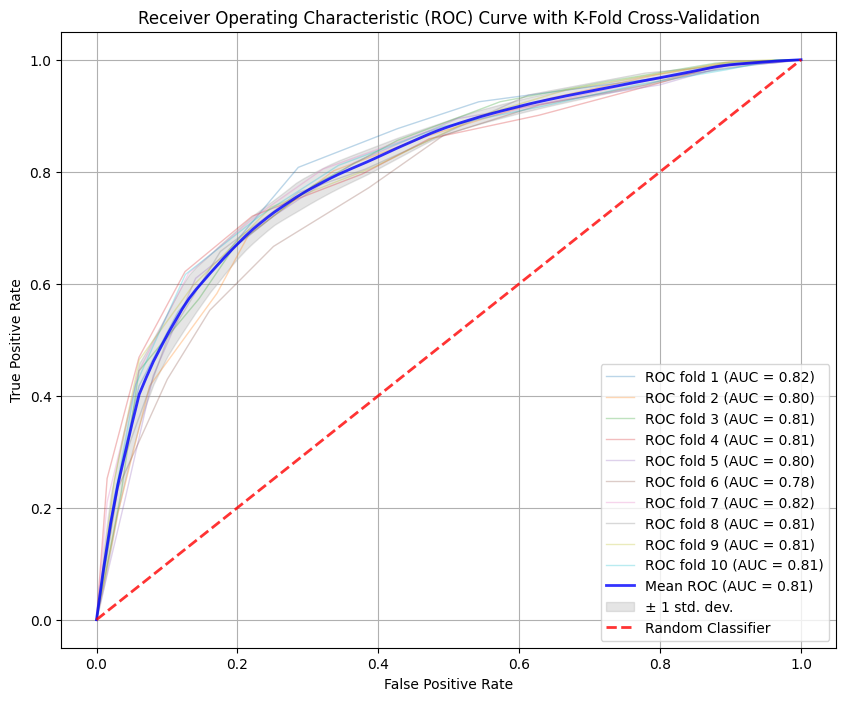

ROC curves and mean ROC curve with standard deviation plotted successfully.


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Create a new figure and axes for the plot
plt.figure(figsize=(10, 8))

# Plot individual ROC curves for each fold
for i, (fpr, tpr, auc) in enumerate(zip(fprs_test, tprs_test, aucs_test)):
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i+1} (AUC = {auc:.2f})')

# Calculate mean ROC curve and AUC
mean_fpr = np.linspace(0, 1, 100) # Common FPR values for interpolation
tprs_interp = []
for i, fpr in enumerate(fprs_test):
    tprs_interp.append(np.interp(mean_fpr, fpr, tprs_test[i]))

mean_tpr = np.mean(tprs_interp, axis=0)
std_tpr = np.std(tprs_interp, axis=0)
mean_auc = np.mean(aucs_test)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot standard deviation as a shaded area
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.2, label='\u00b1 1 std. dev.')

# Plot random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Random Classifier', alpha=0.8)

# Add labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve with K-Fold Cross-Validation')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("ROC curves and mean ROC curve with standard deviation plotted successfully.")

## Plot Precision, Recall, and Accuracy vs. Threshold

### Subtask:
Plot precision, recall, and accuracy metrics against a range of classification thresholds on a single graph, indicating each metric with different colors.

**Reasoning**:
To visualize how precision, recall, and accuracy vary with the classification threshold, I will iterate through a range of thresholds from 0 to 1. For each threshold, I'll convert the predicted probabilities to binary predictions and then calculate the accuracy, precision (weighted), and recall (weighted) for each fold. After collecting these scores across all folds for each threshold, I'll compute their means and plot them against the thresholds on a single graph with appropriate labels and a legend.

Calculating precision, recall, and accuracy for various thresholds...


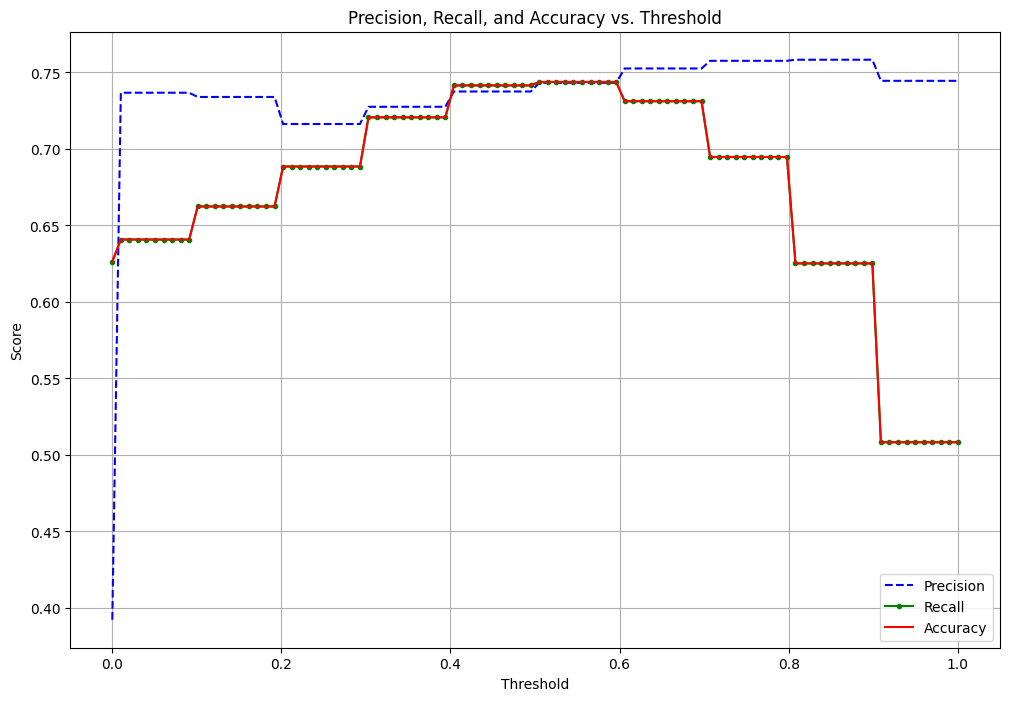

Precision, Recall, and Accuracy vs. Threshold plot generated.


In [21]:
from sklearn.metrics import precision_recall_curve, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

print("Calculating precision, recall, and accuracy for various thresholds...")

# Define a range of thresholds
thresholds = np.linspace(0, 1, 100)

# Initialize lists to store scores for each threshold across all folds
precision_thresholds = []
recall_thresholds = []
accuracy_thresholds = []

for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_test_fold = X.iloc[test_index]
    y_test_fold = y.iloc[test_index]

    # Make predictions (probabilities) for the positive class on test data
    # Ensure the model is refit for each fold as the loop progresses
    model.fit(X.iloc[train_index], y.iloc[train_index])
    y_test_pred_proba = model.predict_proba(X_test_fold)[:, 1]

    fold_precision = []
    fold_recall = []
    fold_accuracy = []

    for t in thresholds:
        y_pred_at_threshold = (y_test_pred_proba >= t).astype(int)

        acc = accuracy_score(y_test_fold, y_pred_at_threshold)
        prec = precision_score(y_test_fold, y_pred_at_threshold, average='weighted', zero_division=0)
        rec = recall_score(y_test_fold, y_pred_at_threshold, average='weighted', zero_division=0)

        fold_accuracy.append(acc)
        fold_precision.append(prec)
        fold_recall.append(rec)

    precision_thresholds.append(fold_precision)
    recall_thresholds.append(fold_recall)
    accuracy_thresholds.append(fold_accuracy)

# Convert to numpy arrays for easier calculation of mean and std
precision_thresholds = np.array(precision_thresholds)
recall_thresholds = np.array(recall_thresholds)
accuracy_thresholds = np.array(accuracy_thresholds)

# Calculate mean scores across folds for each threshold
mean_precision = np.mean(precision_thresholds, axis=0)
mean_recall = np.mean(recall_thresholds, axis=0)
mean_accuracy = np.mean(accuracy_thresholds, axis=0)

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(thresholds, mean_precision,'--', label='Precision', color='blue')
plt.plot(thresholds, mean_recall, '.-', label='Recall', color='green')
plt.plot(thresholds, mean_accuracy, label='Accuracy', color='red')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and Accuracy vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

print("Precision, Recall, and Accuracy vs. Threshold plot generated.")